<a href="https://colab.research.google.com/github/fikhrihanif/Fikhri-Hanif-Histogram-Normalization-Dan-Histogram-Equalization/blob/main/Tugas2_ImageProcessing_Histogram_Normalization_Dan_Histogram_Equalization_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Library

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Baca Gambar

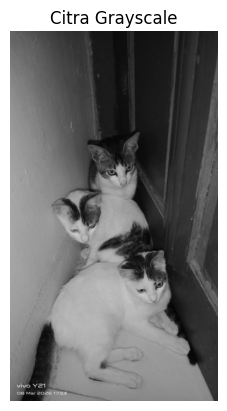

In [18]:
image = cv2.imread('Gambar.jpeg')

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Citra Grayscale")
plt.axis("off")
plt.show()

Menghitung Histogram Manual

In [19]:
histogram = np.zeros(256)

for pixel in gray.flatten():
    histogram[pixel] += 1

Histogram Sebelum Normalisasi

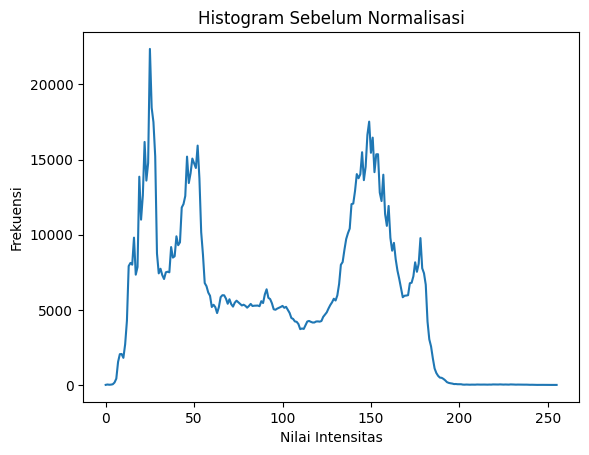

In [20]:
plt.figure()
plt.title("Histogram Sebelum Normalisasi")
plt.xlabel("Nilai Intensitas")
plt.ylabel("Frekuensi")
plt.plot(histogram)
plt.show()

Normalisasi Histogram

In [21]:
total_pixels = gray.shape[0] * gray.shape[1]

normalized_histogram = histogram / total_pixels

Histogram Setelah Normalisasi

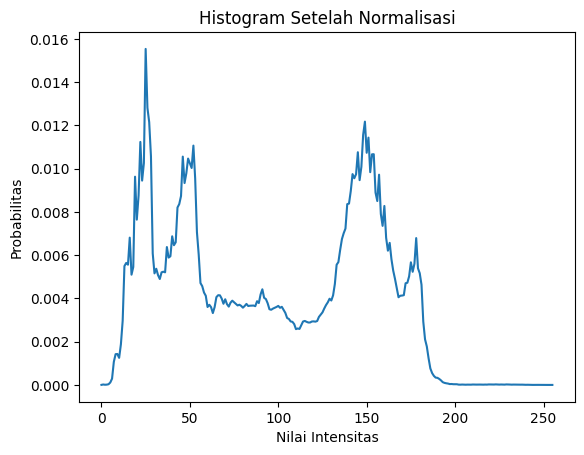

In [22]:
plt.figure()
plt.title("Histogram Setelah Normalisasi")
plt.xlabel("Nilai Intensitas")
plt.ylabel("Probabilitas")
plt.plot(normalized_histogram)
plt.show()

Menghitung CDF

In [23]:
cdf = np.zeros(256)
cdf[0] = normalized_histogram[0]

for i in range(1,256):
    cdf[i] = cdf[i-1] + normalized_histogram[i]

Transformasi Histogram Equalization

In [24]:
equalization_map = np.floor(255 * cdf).astype(np.uint8)

Membuat Citra Hasil Equalization

In [25]:
equalized_image = equalization_map[gray]

Hasil Equalization

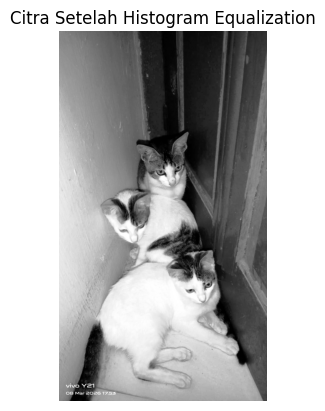

In [26]:
plt.imshow(equalized_image, cmap='gray')
plt.title("Citra Setelah Histogram Equalization")
plt.axis("off")
plt.show()

Histogram Setelah Equalization

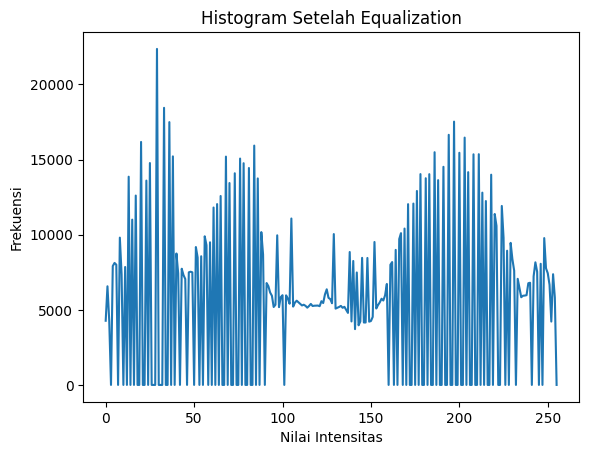

In [27]:
hist_eq = np.zeros(256)

for pixel in equalized_image.flatten():
    hist_eq[pixel] += 1

plt.figure()
plt.title("Histogram Setelah Equalization")
plt.xlabel("Nilai Intensitas")
plt.ylabel("Frekuensi")
plt.plot(hist_eq)
plt.show()

In [28]:
print("Nilai pixel asli:")
print(gray[0:5,0:5])

print("Nilai pixel setelah equalization:")
print(equalized_image[0:5,0:5])

Nilai pixel asli:
[[ 97  98  99  97  95]
 [ 98  99  99  98  96]
 [ 99 100 100 100  98]
 [ 99 101 101 101  99]
 [100 101 102 102 100]]
Nilai pixel setelah equalization:
[[130 131 132 130 129]
 [131 132 132 131 129]
 [132 133 133 133 131]
 [132 134 134 134 132]
 [133 134 135 135 133]]
